# Melbourne Housing Data Analysis

This notebook contains exploratory data analysis of the Melbourne housing dataset.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the Melbourne housing dataset
df = pd.read_csv('csvs/melb_data.csv')

# Display the first few rows of the dataset
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


# Data Exploration and Cleaning

Let's first examine our dataset's structure and check for any missing values or anomalies.

In [3]:
# Display dataset information
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float

In [4]:
# shape represents the number of rows and columns in the DataFrame
df.shape


(13580, 21)

In [5]:
# Check for missing values
print("Missing Values:")
df.isnull().sum()

Missing Values:


Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

In [6]:
# Display basic statistics
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


 Handling Missing Values


In [7]:
# Remove rows with missing values
df_clean = df.dropna()
df_clean

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.00,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.00,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.00,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,...,2.0,0.0,245.0,210.00,1910.0,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,...,1.0,2.0,256.0,107.00,1890.0,Yarra,-37.80600,144.99540,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12205,Whittlesea,30 Sherwin St,3,h,601000.0,S,Ray,29/07/2017,35.5,3757.0,...,2.0,1.0,972.0,149.00,1996.0,Whittlesea,-37.51232,145.13282,Northern Victoria,2170.0
12206,Williamstown,75 Cecil St,3,h,1050000.0,VB,Williams,29/07/2017,6.8,3016.0,...,1.0,0.0,179.0,115.00,1890.0,Hobsons Bay,-37.86558,144.90474,Western Metropolitan,6380.0
12207,Williamstown,2/29 Dover Rd,1,u,385000.0,SP,Williams,29/07/2017,6.8,3016.0,...,1.0,1.0,0.0,35.64,1967.0,Hobsons Bay,-37.85588,144.89936,Western Metropolitan,6380.0
12209,Windsor,201/152 Peel St,2,u,560000.0,PI,hockingstuart,29/07/2017,4.6,3181.0,...,1.0,1.0,0.0,61.60,2012.0,Stonnington,-37.85581,144.99025,Southern Metropolitan,4380.0



 Handling Duplicates


In [8]:
# Remove duplicate rows
n_duplicates = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
df_clean.describe() 

# Check in the above cell the data has been changed

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,6196.000000,6.196000e+03,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,2.931407,1.068828e+06,9.751097,3101.947708,2.902034,1.576340,1.573596,471.006940,141.568645,1964.081988,-37.807904,144.990201,7435.489509
std,0.971079,6.751564e+05,5.612065,86.421604,0.970055,0.711362,0.929947,897.449881,90.834824,38.105673,0.075850,0.099165,4337.698917
min,1.000000,1.310000e+05,0.000000,3000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1196.000000,-38.164920,144.542370,389.000000
25%,2.000000,6.200000e+05,5.900000,3044.000000,2.000000,1.000000,1.000000,152.000000,91.000000,1940.000000,-37.855438,144.926198,4383.750000
50%,3.000000,8.800000e+05,9.000000,3081.000000,3.000000,1.000000,1.000000,373.000000,124.000000,1970.000000,-37.802250,144.995800,6567.000000
75%,4.000000,1.325000e+06,12.400000,3147.000000,3.000000,2.000000,2.000000,628.000000,170.000000,2000.000000,-37.758200,145.052700,10175.000000
max,8.000000,9.000000e+06,47.400000,3977.000000,9.000000,8.000000,10.000000,37000.000000,3112.000000,2018.000000,-37.457090,145.526350,21650.000000


Date Conversion 
##### *you need to figure out if any conversions are needed in your dataset to improve your understanding of the dataset* 
Converting date strings to datetime objects is crucial for several reasons:
1. Enables time-based analysis (e.g., seasonal trends in house prices)
2. Allows extraction of useful features like month, year, or day of week
3. Makes it possible to calculate time-based metrics (e.g., days on market)
4. Ensures proper sorting and comparison of dates

In [9]:
# Check original date format
print("Original date format:")
print(df_clean['Date'].head())

Original date format:
1    4/02/2016
2    4/03/2017
4    4/06/2016
6    7/05/2016
7    8/10/2016
Name: Date, dtype: object


In [10]:
# Convert dates
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y')

print("Converted date format:")
print(df_clean['Date'].head())

# Extract month and year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Year'] = df_clean['Date'].dt.year

Converted date format:
1   2016-02-04
2   2017-03-04
4   2016-06-04
6   2016-05-07
7   2016-10-08
Name: Date, dtype: datetime64[ns]


In [11]:
# Group data by 'Year' and calculate multiple statistics for 'Price':
# - mean: average price for each year
# - count: number of houses sold each year
# - std: standard deviation (price variation) for each year
yearly_stats = df_clean.groupby('Year')['Price'].agg(['mean', 'count', 'std'])
print("\nYearly Price Statistics:")
yearly_stats


Yearly Price Statistics:


,mean,count,std
Year,,,
2016,1.103024e+06,3483,685349.278518
2017,1.024927e+06,2713,659370.766640


In [12]:
# Monthly average prices
monthly_avg = df_clean.groupby('Month')['Price'].mean().round(2)
print("\nAverage Price by Month:")
print(monthly_avg)

# Price trends over time
df_clean['YearMonth'] = df_clean['Date'].dt.to_period('M')
monthly_trend = df_clean.groupby('YearMonth')['Price'].mean()
print("\nNumber of distinct months:", len(monthly_trend))


Average Price by Month:
Month
2     1091397.70
3     1140263.59
4     1007807.38
5     1084880.02
6     1075925.67
7      868746.96
8     1118089.98
9     1107864.92
10    1140362.80
11    1178320.96
12    1203314.67
Name: Price, dtype: float64

Number of distinct months: 17


#### *Understanding Correlations*

Correlation tells us how two things are related:
- **+1**: When one goes up, the other goes up (strong positive relationship)
- **0**: No relationship at all
- **-1**: When one goes up, the other goes down (strong negative relationship)

Why it matters for house prices:
- Helps us see if prices are higher in certain months
- Shows if prices are going up or down over the years

In [13]:
# Correlation of time features with price
time_correlations = df_clean[['Price', 'Month', 'Year']].corr()['Price'].sort_values(ascending=False)
print("\nCorrelations with Price:")
print(time_correlations)


Correlations with Price:
Price    1.000000
Month    0.051164
Year    -0.057392
Name: Price, dtype: float64


# Basic Plotting with Matplotlib

Let's learn plotting step by step:
1. Simple line plot
2. Basic bar plot
3. Then combine them in subplots

In [14]:
# Calculate number of sales per month
monthly_sales = df_clean.groupby('Month').size()
print("Number of sales by month:")
print(monthly_sales)
print(monthly_sales.index)
print(monthly_sales.values)

Number of sales by month:
Month
2     244
3     286
4     491
5     984
6     881
7     993
8     544
9     526
10    296
11    630
12    321
dtype: int64
Index([2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='Month')
[244 286 491 984 881 993 544 526 296 630 321]


I saw that there is no value for January\
So to double check i ran the following cells

In [15]:
# Check all unique months in the dataset
print("\nUnique months in the dataset:")
print(sorted(df_clean['Month'].unique()))


Unique months in the dataset:
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [16]:
# Check the date range of our dataset
print("\nDate range of the dataset:")
print(f"Start date: {df_clean['Date'].min()}")
print(f"End date: {df_clean['Date'].max()}")


Date range of the dataset:
Start date: 2016-02-04 00:00:00
End date: 2017-08-12 00:00:00


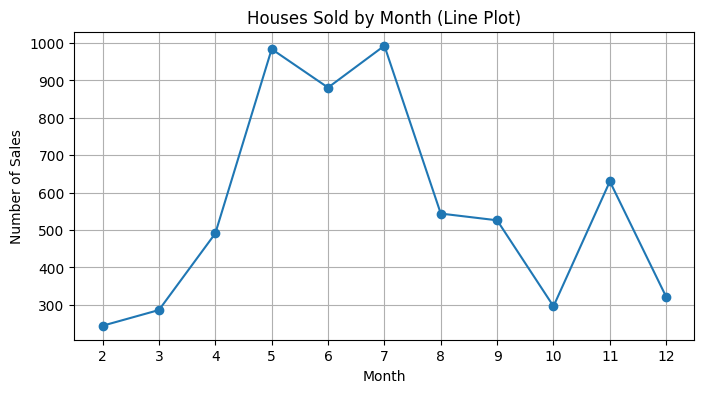

In [17]:
# 1. Simple line plot
plt.figure(figsize=(8, 4))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')  # use actual month numbers and values
plt.title('Houses Sold by Month (Line Plot)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(monthly_sales.index)  # ensure x-axis shows all month numbers
plt.grid(True)  # adds a grid
plt.show()

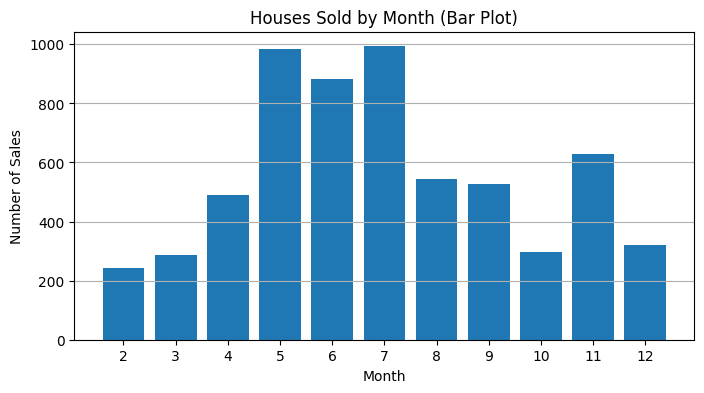

In [18]:
# 2. Basic bar plot
plt.figure(figsize=(8, 4))
plt.bar(monthly_sales.index, monthly_sales.values)  # use actual month numbers from our data
plt.title('Houses Sold by Month (Bar Plot)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(monthly_sales.index)  # ensure x-axis shows all month numbers
plt.grid(True, axis='y')  # add horizontal grid lines for better readability
plt.show()

Seeing both sales volume and average prices for each month helps us:
- Spot seasonal patterns (some months are busier or pricier)
- Decide if "Month" should be a feature in our regression model
- Check if sales volume affects prices
- Quickly compare market activity and price trends side by side

This makes it easier to choose the right features for predicting house prices.

*So you also have to think about what data will help you find features for your ml model*

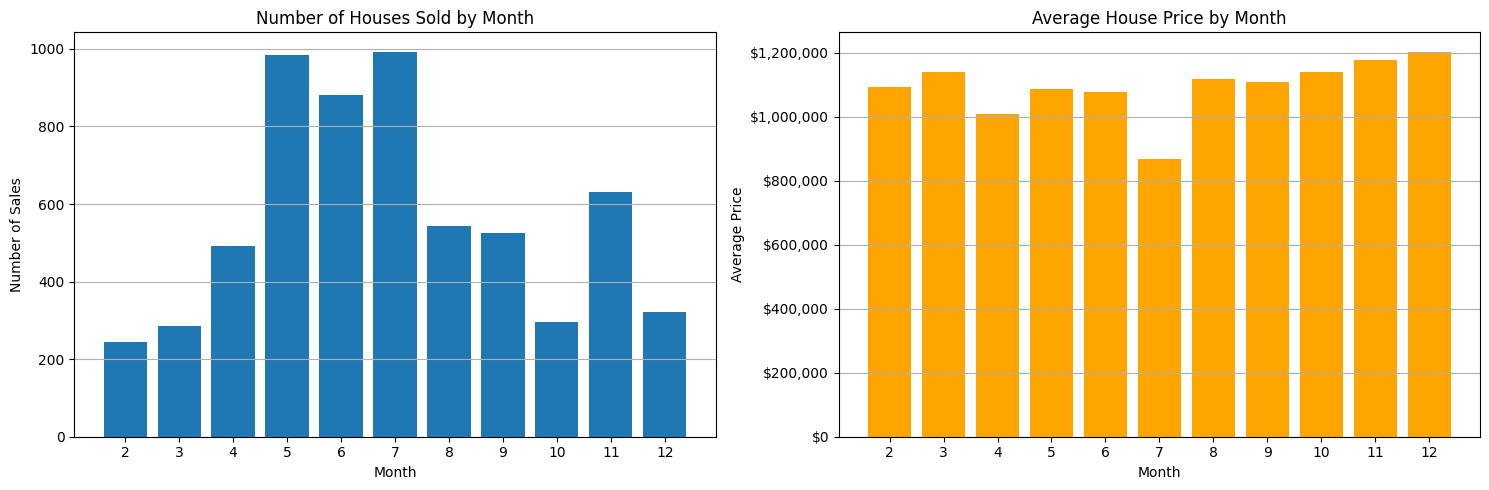

In [19]:
# 3. Combining plots using subplots
# Create a figure with two subplots side by side (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left subplot: Number of sales
ax1.bar(monthly_sales.index, monthly_sales.values)
ax1.set_title('Number of Houses Sold by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Sales')
ax1.set_xticks(monthly_sales.index)  # set x-axis ticks to match our data
ax1.grid(True, axis='y')

# Right subplot: Average prices
monthly_prices = df_clean.groupby('Month')['Price'].mean()
ax2.bar(monthly_prices.index, monthly_prices.values, color='orange')
ax2.set_title('Average House Price by Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average Price')
ax2.set_xticks(monthly_prices.index)  # set x-axis ticks to match our data
ax2.grid(True, axis='y')

# Format price labels on y-axis to be more readable (in millions)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Data Visualization
1. **Correlation Heatmap** shows:
   - Which features are strongly related to price (helps choose important features)
   - Which features might interfere with each other (avoid using both)

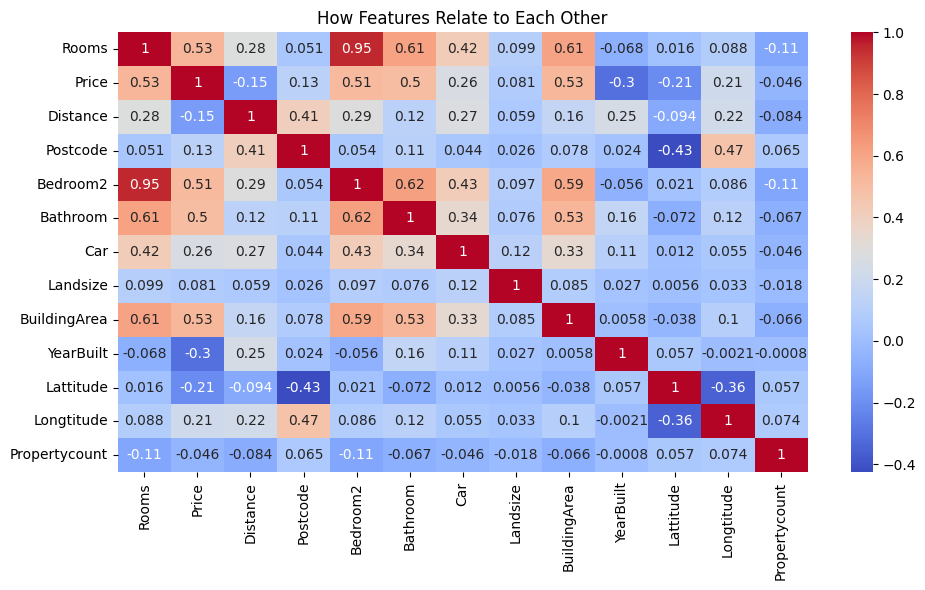

In [20]:
# Create correlation heatmap
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('How Features Relate to Each Other')
plt.tight_layout()
plt.show()




2. **Price Distribution** tells us:
   - If prices are spread normally or skewed (might need to transform data)
   - If there are unusual prices (potential outliers)

These insights help us prepare data properly for our price prediction model.

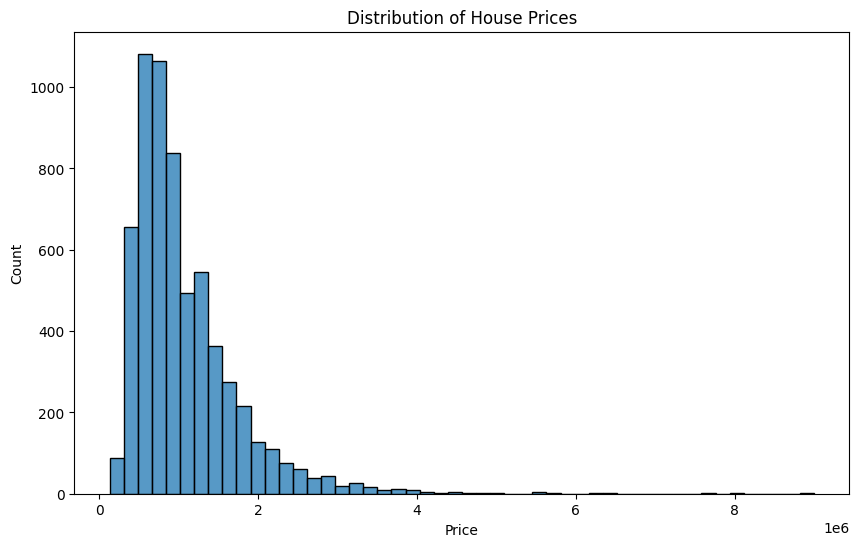

In [21]:
# Look at price distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='Price', bins=50)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


# Preparing Data for Linear Regression

### What is Linear Regression?
Linear regression tries to predict house prices by finding relationships between features (like size, location) and price. Think of it like this:
- Price = (Impact of Size × Size) + (Impact of Location × Location) + ... + Base Price

### Why Prepare Data?
1. **Handle Categories**: Turn text data (like 'Suburb') into numbers
2. **Scale Numbers**: Make all number-based features similar in size (so 'Price' isn't overwhelmed by 'LandSize')
3. **Choose Features**: Pick features that actually help predict price (from our earlier analysis)

Let's prepare our data following these steps!

In [22]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Create a copy of the cleaned dataframe
df_encoded = df_clean.copy()

# Convert Date to datetime with the correct format (dd/mm/yyyy)
if not pd.api.types.is_datetime64_any_dtype(df_encoded['Date']):
    df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], format='%d/%m/%Y')

# Extract month and year from Date
df_encoded['Month'] = df_encoded['Date'].dt.month
df_encoded['Year'] = df_encoded['Date'].dt.year

# Drop unnecessary columns
df_encoded = df_encoded.drop(['Date', 'Address'], axis=1)

# Identify categorical columns to encode
categorical_columns = ['Suburb', 'Type', 'Method', 'SellerG', 'CouncilArea', 'Regionname']

# Encode each categorical column
for column in categorical_columns:
    # Create a label encoder
    le = LabelEncoder()
    # Fill NA with a placeholder
    df_encoded[column] = df_encoded[column].fillna('Unknown')
    # Fit and transform the column
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Fill remaining numerical NA values with median
numerical_columns = df_encoded.select_dtypes(include=['float64', 'int64']).columns
for column in numerical_columns:
    df_encoded[column] = df_encoded[column].fillna(df_encoded[column].median())

print("Data encoding completed. Shape of encoded dataset:", df_encoded.shape)
print("\nAll columns in encoded dataset:")
print(df_encoded.columns.tolist())
print("\nSample of encoded categorical data:")
print(df_encoded[categorical_columns].head())

Data encoding completed. Shape of encoded dataset: (6196, 22)

All columns in encoded dataset:
['Suburb', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'Month', 'Year', 'YearMonth']

Sample of encoded categorical data:
   Suburb  Type  Method  SellerG  CouncilArea  Regionname
1       0     0       1       18           29           2
2       0     0       3       18           29           2
4       0     0       4      112           29           2
6       0     0       1      112           29           2
7       0     0       1      112           29           2


### Linear Regression Steps
1. Split data into training and testing sets
2. Train the model using training data
3. Make predictions and evaluate the model
4. Check which features were most important

In [23]:
# Import necessary libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Prepare features (X) and target variable (y)
X = df_encoded.drop('Price', axis=1)  # All columns except Price
y = df_encoded['Price']  # Price is what we want to predict

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:,.0f}")
print(f"Root Mean Squared Error: {mse ** 0.5:,.0f}")

TypeError: float() argument must be a string or a real number, not 'Period'

In [ ]:
# Look at feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_)
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Show top 10 most important features
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).round(2))

In [ ]:
# Compare some actual vs predicted prices
comparison = pd.DataFrame({
    'Actual Price': y_test[:5],
    'Predicted Price': y_pred[:5],
    'Difference': y_test[:5] - y_pred[:5]
})
print("\nSample Predictions vs Actual Prices:")
print(comparison.round(2))

In [ ]:
# Create a scatter plot of actual vs predicted prices
plt.figure(figsize=(10, 6))

# Plot actual vs predicted prices
plt.scatter(y_test, y_pred, alpha=0.5)

# Add a perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()

# Format price labels to be more readable (in millions)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Calculate and print some additional metrics
print("\nPrediction Analysis:")
print(f"Average Actual Price: ${y_test.mean():,.2f}")
print(f"Average Predicted Price: ${y_pred.mean():,.2f}")
print(f"Average Absolute Error: ${abs(y_test - y_pred).mean():,.2f}")
print(f"Average Percentage Error: {(abs(y_test - y_pred) / y_test * 100).mean():.1f}%")

NameError: name 'y_test' is not defined

<Figure size 1000x600 with 0 Axes>